In [284]:
import pandas as pd
import requests
import random
from bs4 import BeautifulSoup
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [285]:
import config
from config import client_id, client_secret
from IPython.display import IFrame
import spotipy
import json
from spotipy.oauth2 import SpotifyClientCredentials
import requests
import base64

In [286]:
def get_spotify_token(client_id, client_secret):

    client_credentials = f"{client_id}:{ client_secret}"
    client_credentials_b64 = base64.b64encode(client_credentials.encode()).decode()

    headers = {
        "Authorization": f"Basic {client_credentials_b64}",
        "Content-Type": "application/x-www-form-urlencoded"
    }
    data = {
        "grant_type": "client_credentials"
    }

    response = requests.post("https://accounts.spotify.com/api/token", headers=headers, data=data)

    if response.status_code == 200:
        token = response.json().get("access_token")
        return token
    else:
        raise Exception(f"Failed to get token: {response.status_code} {response.text}")

token = get_spotify_token(client_id, client_secret)
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(client_id= config.client_id,
                                                           client_secret= config.client_secret))

In [287]:
url = "https://www.billboard.com/charts/hot-100/"

In [288]:
response = requests.get(url)

In [289]:
soup = BeautifulSoup(response.content)

In [290]:
# DAY 1: Collecting Data 📊
# Objective:
# 1️⃣ Scrape trending songs:

# Scrape the Billboard Hot 100 (Billboard Charts) to collect the top 100 songs and respective artists.
# Store this in a DataFrame with the columns:
# "song_title" and "artist"
# These songs will form a "Trending" category that users can choose from.

In [ ]:
song = [song.get_text(strip=True) for song in soup.select('li h3.c-title')]
song

In [ ]:
artist = [artist.get_text(strip=True) for artist in soup.select("li span.c-label.a-no-trucate")]
artist

In [293]:
top_100songs_dict = {"artist":artist ,"song": song}
top100_df = pd.DataFrame(top_100songs_dict)
top100_df

,artist,song
0,Alex Warren,Ordinary
1,Sabrina Carpenter,Manchild
2,Morgan Wallen Featuring Tate McRae,What I Want
3,Morgan Wallen,Just In Case
4,Kendrick Lamar & SZA,Luther
...,...,...
95,Max McNown,Better Me For You (Brown Eyes)
96,Josh Ross,Single Again
97,KATSEYE,Gnarly
98,mgk,Cliche


In [294]:
# DAY 2: Basic Recommendation System Setup 🤖
# Objective:
# 1️⃣ User Song Type Selection (Basic Recommender Prototype)

# Create a program where the user can input a music type rather than a specific song.
# The user can choose from:
# "High Energy", "Chill Vibes", "Rock", "Trending Now", etc.
# For now, if the user selects "Trending Now," return a random popular song from the Billboard Hot 100 DataFrame.
# If they select another type, simply acknowledge their selection (without returning a song yet).

In [295]:
# DAY 3: Clustering Songs for Personalized Recommendations 🎧
# Objective:
# 1️⃣ Cluster songs based on their musical characteristics

# Use unsupervised learning (e.g., K-Means, DBSCAN, Hierarchical Clustering) to group similar songs.
# Identify 5 to 20 natural clusters in your dataset based on audio features.
# Assign a cluster ID to each song in the dataset.
# 2️⃣ Label the Clusters (Genre & Mood-Based Categorization)

In [296]:
import pandas as pd
df = pd.read_csv("audio_features_dataset_curated.csv")
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
42996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
42997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
42998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [297]:
# Clean the 'album_name' column
df['album_name'] = (
    df['album_name']
    .str.replace('#', '', regex=False)       # Remove '#'
    .str.replace(r'\.\.\.', '', regex=True)  # Remove '...'
    .str.strip()                             # Remove leading/trailing whitespace
)

In [298]:
# Drop duplicates
df = df.drop_duplicates()
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
42996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
42997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
42998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [299]:
# Handle missing values (drop rows with missing album_name)
df = df.dropna(subset=['album_name'])
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
42996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
42997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
42998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [300]:
# Show a few cleaned entries
print(df['album_name'].head())

0                                               Comedy
1                                     Ghost (Acoustic)
2                                       To Begin Again
3    Crazy Rich Asians (Original Motion Picture Sou...
4                                              Hold On
Name: album_name, dtype: object


In [301]:
df.info()             # Data types and non-null counts
df.describe() 

<class 'pandas.core.frame.DataFrame'>
Index: 34722 entries, 0 to 42999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          34722 non-null  object 
 1   artists           34722 non-null  object 
 2   album_name        34722 non-null  object 
 3   track_name        34722 non-null  object 
 4   popularity        34722 non-null  int64  
 5   duration_ms       34722 non-null  int64  
 6   explicit          34722 non-null  bool   
 7   danceability      34722 non-null  float64
 8   energy            34722 non-null  float64
 9   key               34722 non-null  int64  
 10  loudness          34722 non-null  float64
 11  mode              34722 non-null  int64  
 12  speechiness       34722 non-null  float64
 13  acousticness      34722 non-null  float64
 14  instrumentalness  34722 non-null  float64
 15  liveness          34722 non-null  float64
 16  valence           34722 non-null  float64
 17

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,34722.000000,3.472200e+04,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000,34722.000000
mean,35.887622,2.321116e+05,0.569844,0.622634,5.313836,-8.150473,0.648667,0.071354,0.313615,0.134507,0.196823,0.471432,121.522294,3.906227
std,24.206757,9.683838e+04,0.166838,0.247554,3.566131,4.893248,0.477394,0.073832,0.330176,0.293757,0.173776,0.253635,29.354942,0.408243
min,0.000000,1.745300e+04,0.000000,0.000020,0.000000,-43.043000,0.000000,0.000000,0.000001,0.000000,0.009860,0.000000,0.000000,0.000000
25%,18.000000,1.812400e+05,0.459000,0.454000,2.000000,-9.671750,0.000000,0.034100,0.022200,0.000000,0.096200,0.260000,98.047000,4.000000
50%,40.000000,2.180440e+05,0.581000,0.664000,5.000000,-6.939000,1.000000,0.045000,0.169000,0.000021,0.125000,0.456000,122.011000,4.000000
75%,54.000000,2.638650e+05,0.694000,0.829000,8.000000,-5.069000,1.000000,0.072600,0.584000,0.012600,0.241000,0.673000,140.000000,4.000000
max,100.000000,3.601693e+06,0.975000,1.000000,11.000000,1.821000,1.000000,0.924000,0.996000,1.000000,0.994000,0.995000,243.372000,5.000000


In [302]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
42996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
42997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
42998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [303]:
# Step 1: Select relevant audio features
# Common features: energy, danceability, tempo, loudness, valence, etc.
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo']

In [336]:
df[features]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949
...,...,...,...,...,...,...,...,...,...
42995,0.172,0.2350,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995
42996,0.174,0.1170,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239
42997,0.629,0.3290,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378
42998,0.587,0.5060,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960


In [335]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster_id,cluster_label
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,5,Upbeat Rock
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,2,Ambient / Instrumental
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,2,Ambient / Instrumental
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,13,NaN
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,1,High Energy Dance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,10,NaN
42996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,10,NaN
42997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,3,Emotional Pop
42998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,1,High Energy Dance


In [305]:
# Step 2: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [306]:
# Step 3: Optional - Elbow Method to find optimal K
inertia = []
k_range = range(5, 21)  # 5 to 20 clusters

In [307]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

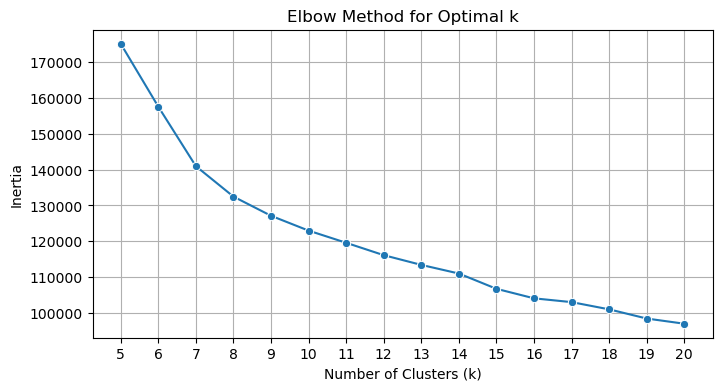

In [308]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
sns.lineplot(x=list(k_range), y=inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [309]:
# Step 4: KMeans Clustering with chosen k
k = 15  
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster_id'] = kmeans.fit_predict(X_scaled)

C:\Users\Expertlead Admin\AppData\Local\Temp\ipykernel_28788\2373514354.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster_id'] = kmeans.fit_predict(X_scaled)


In [310]:
cluster_labels = {0: "Chill Acoustic",1: "High Energy Dance",2: "Ambient / Instrumental",3: "Emotional Pop",
    4: "Rap / Spoken Word",5: "Upbeat Rock",6: "Relaxing Instrumentals",7: "Happy Pop",8: "Sad Ballads",
    9: "Fast-Paced EDM"}

In [311]:
df['cluster_label'] = df['cluster_id'].map(cluster_labels)

C:\Users\Expertlead Admin\AppData\Local\Temp\ipykernel_28788\1100114894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster_label'] = df['cluster_id'].map(cluster_labels)


In [312]:
# View sample with cluster labels
print(df[['album_name', 'cluster_id'] + features].head())

                                          album_name  cluster_id  \
0                                             Comedy           5   
1                                   Ghost (Acoustic)           2   
2                                     To Begin Again           2   
3  Crazy Rich Asians (Original Motion Picture Sou...          13   
4                                            Hold On           1   

   danceability  energy  loudness  speechiness  acousticness  \
0         0.676  0.4610    -6.746       0.1430        0.0322   
1         0.420  0.1660   -17.235       0.0763        0.9240   
2         0.438  0.3590    -9.734       0.0557        0.2100   
3         0.266  0.0596   -18.515       0.0363        0.9050   
4         0.618  0.4430    -9.681       0.0526        0.4690   

   instrumentalness  liveness  valence    tempo  
0          0.000001    0.3580    0.715   87.917  
1          0.000006    0.1010    0.267   77.489  
2          0.000000    0.1170    0.120   76.332  
3     

In [313]:
# Optional: Save to CSV
df.to_csv("clustered_songs.csv", index=False)

In [314]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster_id,cluster_label
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,5,Upbeat Rock
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,2,Ambient / Instrumental
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,2,Ambient / Instrumental
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,13,NaN
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,1,High Energy Dance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,10,NaN
42996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,mindfulness - Soft Rain for Mindful Meditation...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,10,NaN
42997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,3,Emotional Pop
42998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,1,High Energy Dance


In [315]:
# Function to scrape Billboard Hot 100
def get_billboard_hot_100():
    url = "https://www.billboard.com/charts/hot-100/"

In [316]:
# User input and logic
def recommend_song():
    music_types = ["High Energy", "Chill Vibes", "Rock", "Trending Now"]
    print("Choose a music type:")
    for i, mtype in enumerate(music_types, 1):
        print(f"{i}. {mtype}")

    choice = input("Enter your choice (name or number): ").strip()

    if choice.isdigit() and 1 <= int(choice) <= len(music_types):
        selected = music_types[int(choice)-1]
    elif choice in music_types:
        selected = choice
    else:
        print("Invalid selection.")
        return

    if selected == "Trending Now":
        songs = get_billboard_hot_100()
        if songs:
            print("\n🎵 Recommended Trending Song:")
            print(random.choice(songs))
        else:
            print("Couldn't fetch trending songs at the moment.")
    else:
        print(f"\nYou selected: {selected}. (Feature coming soon!)")

In [317]:
def play_song(track_id):
    return IFrame(src="https://open.spotify.com/embed/track/"+track_id,
       width="320",
       height="80",
       frameborder="0",
       allowtransparency="true",
       allow="encrypted-media",
      )

In [318]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'cluster_id', 'cluster_label'],
      dtype='object')

In [319]:
def recommend_song():
    print("categories that is available [Trending now, Relaxing Instrumentals,  Rap / Spoken Word, High Energy Dance, Emotional Pop, Upbeat Rock, Ambient / Instrumental, Chill Acoustic]")
    choice_ = input("Enter your choice of category:")
    if choice_ == "Trending now":
        song_name = random.choice(top100_df['song'])
        recommended_billboard_song_id = sp.search(q=song_name,limit=1,market="GB")["tracks"]["items"][0]["id"]
        play_song(recommended_billboard_song_id)
        print(song_name)
        return play_song(recommended_billboard_song_id)
    else:
        filtered_df = df[df["cluster_label"] == choice_]
        song_id = random.choice(filtered_df['track_id'].tolist())    
        
        return play_song(song_id)

In [356]:
def recommend_song():
    categories = [
        "Trending now", 
        "Relaxing Instrumentals", 
        "Rap / Spoken Word", 
        "High Energy Dance", 
        "Emotional Pop", 
        "Upbeat Rock", 
        "Ambient / Instrumental", 
        "Chill Acoustic"
    ]

    print("Categories that are available:")
    for i, cat in enumerate(categories, 1):
        print(f"{i}. {cat}")

    try:
        choice = int(input("\nEnter the number of your choice: "))
        if 1 <= choice <= len(categories):
            selected_category = categories[choice - 1]
            print(f"\nYou selected: {selected_category}")

            # Use your ClientCredentialsManager here
            sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
                client_id=client_id,
                client_secret=client_secret
            ))

            # Search for a track
            results = sp.search(q=selected_category, type='track', limit=1)
            track = results['tracks']['items'][0]

            track_name = track['name']
            artist_name = track['artists'][0]['name']
            preview_url = track['preview_url']
            external_url = track['external_urls']['spotify']
            song_id = track["id"]

            print(f"\nTrack: {track_name} by {artist_name}")
            if preview_url:
                #print(f"Preview: {preview_url}")
                display(play_song(song_id))
            else:
                #print("No preview available.")
                #print(f"Open in Spotify: {external_url}")
                display(play_song(song_id))

        else:
            print("Invalid choice. Please enter a number from the list.")
    except ValueError:
        print("Please enter a valid number.")


In [357]:
filtered_df = df[df["cluster_label"] == "Rap / Spoken Word"]
song_id = random.choice(filtered_df['track_id'].tolist()) 

In [358]:
filtered_df['track_id']

51       3ILmwMefYZoQh5Cf5jeuUQ
73       2E9viCx0hJKNKNThd2MdGQ
343      37jsciEAFxwyjXx0kV6aO6
518      6Fomnvc3pkLvUQYUkhiQPx
549      2saK0E712wIB3Gf8QLuFYX
                  ...          
42964    2SxRPSQg90BMbSIMtCDVc4
42967    1eZYPovTvmxk3QlVD2VpCX
42973    1d2LyEJ1zZ0gWtlxyZQpDE
42983    6X6wIzuxsh7GVNMPz1xTNa
42989    0XEgJiDryoDd2gIJhVXghd
Name: track_id, Length: 1521, dtype: object

In [359]:
df.cluster_label.unique()

array(['Upbeat Rock', 'Ambient / Instrumental', nan, 'High Energy Dance',
       'Emotional Pop', 'Relaxing Instrumentals', 'Sad Ballads',
       'Happy Pop', 'Rap / Spoken Word', 'Fast-Paced EDM',
       'Chill Acoustic'], dtype=object)

In [360]:
df.cluster_label.unique()

array(['Upbeat Rock', 'Ambient / Instrumental', nan, 'High Energy Dance',
       'Emotional Pop', 'Relaxing Instrumentals', 'Sad Ballads',
       'Happy Pop', 'Rap / Spoken Word', 'Fast-Paced EDM',
       'Chill Acoustic'], dtype=object)

In [364]:
recommend_song()

Categories that are available:
1. Trending now
2. Relaxing Instrumentals
3. Rap / Spoken Word
4. High Energy Dance
5. Emotional Pop
6. Upbeat Rock
7. Ambient / Instrumental
8. Chill Acoustic



Enter the number of your choice:  8



You selected: Chill Acoustic

Track: We Can't Stop by Halloran & Kate
